Step 1: Imported Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

import joblib

print("Libraries imported successfully!")

Libraries imported successfully!


Step 2 - Upload your dataset

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving ev_market_2026.csv to ev_market_2026 (1).csv


STEP 3 — Load the dataset

In [ ]:
df = pd.read_csv("ev_market_2026.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [ ]:
df.head()

,brand,model,year,variant,price_usd,battery_capacity_kwh,range_miles,charging_speed_kw,acceleration_0_60_mph,top_speed_mph,...,body_type,cargo_volume_cubic_ft,weight_kg,safety_rating,autopilot_level,country_of_origin,market_segment,annual_sales_units,customer_rating,warranty_years
0,Volkswagen,ID. Buzz,2023,Performance,104880.80,118.7,400.0,234.5,3.04,195.0,...,Truck,54.2,2015.0,4,2,Germany,Luxury,202182,4.00,4
1,Toyota,bZ Compact SUV,2022,Premium,48217.41,58.8,219.0,148.1,5.77,159.0,...,SUV,69.0,1709.0,4,0,Japan,Mid-range,7146,3.56,3
2,GM/Chevrolet,Bolt EV,2024,Premium,49651.12,58.2,225.0,104.9,6.84,148.0,...,Van,77.0,1533.0,4,1,US,Mid-range,16590,3.70,3
3,Kia,Sportage EV,2024,Long Range,38131.56,102.5,349.0,66.5,4.66,176.0,...,SUV,65.8,1935.0,4,2,South Korea,Mid-range,127201,3.81,3
4,Tesla,Model 3,2022,Long Range,144079.87,93.9,314.0,298.5,5.64,165.0,...,SUV,38.3,2229.0,4,2,US,Luxury,196401,3.83,4


STEP 4 — Understand your dataset

In [ ]:
df.shape

(2000, 24)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   brand                  2000 non-null   object 
 1   model                  2000 non-null   object 
 2   year                   2000 non-null   int64  
 3   variant                2000 non-null   object 
 4   price_usd              2000 non-null   float64
 5   battery_capacity_kwh   2000 non-null   float64
 6   range_miles            2000 non-null   float64
 7   charging_speed_kw      2000 non-null   float64
 8   acceleration_0_60_mph  2000 non-null   float64
 9   top_speed_mph          2000 non-null   float64
 10  horsepower             2000 non-null   float64
 11  torque_nm              2000 non-null   float64
 12  drive_type             2000 non-null   object 
 13  seating_capacity       2000 non-null   int64  
 14  body_type              2000 non-null   object 
 15  carg

In [ ]:
df.describe()

,year,price_usd,battery_capacity_kwh,range_miles,charging_speed_kw,acceleration_0_60_mph,top_speed_mph,horsepower,torque_nm,seating_capacity,cargo_volume_cubic_ft,weight_kg,safety_rating,autopilot_level,annual_sales_units,customer_rating,warranty_years
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,2024.028500,78873.907150,74.662800,261.825500,155.206300,5.630635,164.884500,665.744000,601.311500,5.747000,46.105850,1886.164500,4.377000,1.124500,129653.592000,3.572045,4.579000
std,1.410561,35296.621782,20.082879,71.028238,80.982301,1.417733,20.781244,267.124838,238.706686,1.045245,19.850264,383.772906,0.661127,0.919469,105775.154465,0.270398,1.218812
min,2020.000000,16394.330000,40.000000,150.000000,50.000000,2.500000,118.000000,150.000000,200.000000,2.000000,15.000000,1500.000000,3.000000,0.000000,656.000000,3.000000,3.000000
25%,2023.000000,52325.920000,58.475000,204.000000,90.975000,4.620000,148.000000,442.750000,391.750000,5.000000,28.175000,1570.000000,4.000000,0.000000,44296.500000,3.380000,4.000000
50%,2024.000000,73013.015000,75.100000,261.000000,132.100000,5.670000,165.000000,683.000000,615.500000,5.000000,41.250000,1740.500000,4.000000,1.000000,111188.000000,3.560000,4.000000
75%,2025.000000,99780.157500,87.550000,310.000000,217.300000,6.770000,181.000000,939.250000,845.000000,7.000000,64.700000,2149.500000,5.000000,2.000000,202496.750000,3.750000,5.000000
max,2026.000000,269775.200000,119.900000,447.000000,349.900000,8.000000,200.000000,1000.000000,988.000000,7.000000,80.000000,3000.000000,5.000000,3.000000,499717.000000,4.510000,8.000000


STEP 5 — Check missing values

In [ ]:
df.isnull().sum()

,0
brand,0
model,0
year,0
variant,0
price_usd,0
battery_capacity_kwh,0
range_miles,0
charging_speed_kw,0
acceleration_0_60_mph,0
top_speed_mph,0


In [ ]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [ ]:
df = df.drop_duplicates()

print("New shape:", df.shape)

New shape: (2000, 24)


STEP 6 — Understand our ML problem

In [ ]:
df["annual_sales_units"].describe()

,annual_sales_units
count,2000.000000
mean,129653.592000
std,105775.154465
min,656.000000
25%,44296.500000
50%,111188.000000
75%,202496.750000
max,499717.000000


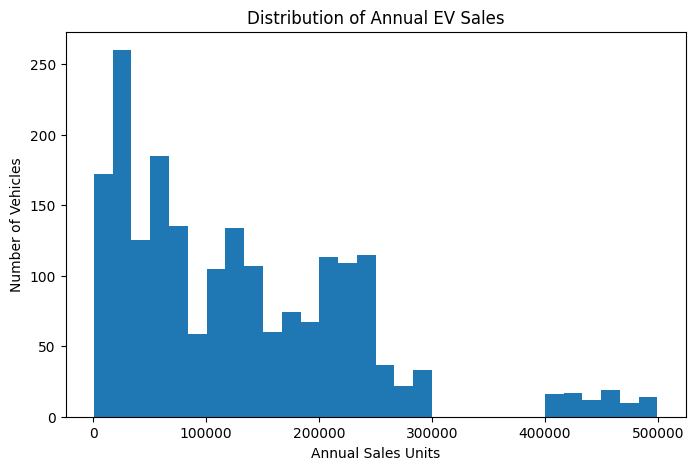

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(df["annual_sales_units"], bins=30)

plt.xlabel("Annual Sales Units")
plt.ylabel("Number of Vehicles")
plt.title("Distribution of Annual EV Sales")

plt.show()

STEP 7 — Separate X and y

In [ ]:
X = df.drop("price_usd", axis=1)
y = df["price_usd"]

In [ ]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (2000, 23)
y shape: (2000,)


STEP 8 — Remove columns that shouldn't be used

In [ ]:
# Remove columns that should not be used for prediction

columns_to_remove = [
    "annual_sales_units",
    "customer_rating"
]

df = df.drop(columns=columns_to_remove, errors="ignore")

print("Remaining columns:")
print(df.columns.tolist())

Remaining columns:
['brand', 'model', 'year', 'variant', 'price_usd', 'battery_capacity_kwh', 'range_miles', 'charging_speed_kw', 'acceleration_0_60_mph', 'top_speed_mph', 'horsepower', 'torque_nm', 'drive_type', 'seating_capacity', 'body_type', 'cargo_volume_cubic_ft', 'weight_kg', 'safety_rating', 'autopilot_level', 'country_of_origin', 'market_segment', 'warranty_years']


Step 10

In [ ]:
X = df.drop(columns=["price_usd"])
y = df["price_usd"]

print("Features:", X.shape)
print("Target:", y.shape)


Features: (2000, 21)
Target: (2000,)


Step 10 - Identify Categorical and Numerical Features

In [ ]:
categorical_columns = X.select_dtypes(include=["object"]).columns.tolist()
numerical_columns = X.select_dtypes(exclude=["object"]).columns.tolist()

print("Categorical:")
print(categorical_columns)

print("\nNumerical:")
print(numerical_columns)

Categorical:
['brand', 'model', 'variant', 'drive_type', 'body_type', 'country_of_origin', 'market_segment']

Numerical:
['year', 'battery_capacity_kwh', 'range_miles', 'charging_speed_kw', 'acceleration_0_60_mph', 'top_speed_mph', 'horsepower', 'torque_nm', 'seating_capacity', 'cargo_volume_cubic_ft', 'weight_kg', 'safety_rating', 'autopilot_level', 'warranty_years']


Step 11 — Preprocess categorical columns

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_columns)
    ],
    remainder="passthrough"
)

print("Preprocessor created successfully!")

Preprocessor created successfully!


Step 12 - Split the data

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 1600
Testing samples: 400


Step 13 — Creating Random Forest model

In [ ]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

print("Model created!")


Model created!


Step 14 — Create ML Pipeline
Categorical data → One-Hot Encoding → Random Forest

In [ ]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ]
)

print("Pipeline created!")


Pipeline created!


Step 15 — Train the model

In [ ]:
pipeline.fit(X_train, y_train)

print("Model training completed!")

Model training completed!


Step 16 — Predict prices


In [ ]:
y_pred = pipeline.predict(X_test)

print("Predictions generated!")

Predictions generated!


In [ ]:
comparison = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred
})

comparison.head(10)

,Actual Price,Predicted Price
0,57566.92,58233.43735
1,110939.31,116873.19265
2,55513.60,44084.45545
3,84123.81,85210.58955
4,41849.58,43511.65395
5,168092.71,153406.71945
6,126875.08,121510.83110
7,88308.20,92563.88015
8,68436.66,70026.32900
9,99786.36,90979.25275


Step 17 — Evaluate the model

MAE - Mean Absolute Error

In [ ]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)

print("Mean Absolute Error:", mae)

Mean Absolute Error: 4421.8155482500015


RMSE- Root Mean Square Error

In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Root Mean Squared Error:", rmse)

Root Mean Squared Error: 7106.155303879046


R² Score

In [ ]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)

R² Score: 0.9557097975218444


Step 18 — Print all results together

In [ ]:
print("----- MODEL PERFORMANCE -----")

print("MAE  :", round(mae, 2))
print("RMSE :", round(rmse, 2))
print("R²   :", round(r2, 4))


----- MODEL PERFORMANCE -----
MAE  : 4421.82
RMSE : 7106.16
R²   : 0.9557


Step 19 - Actual vs Predicted Graph

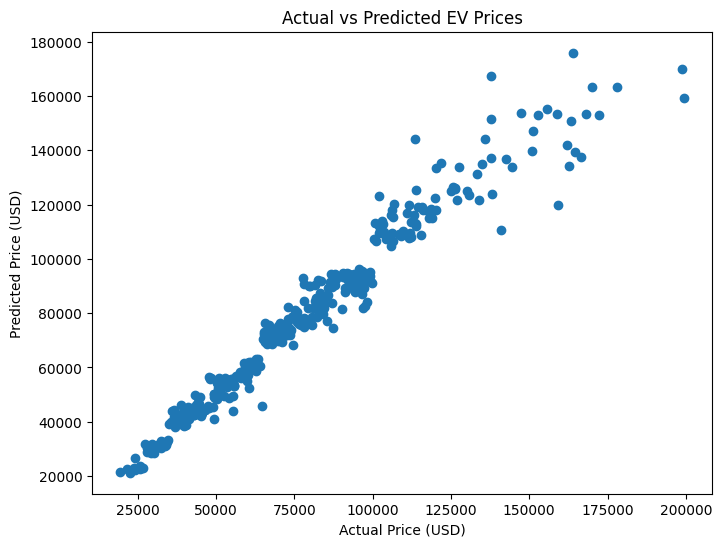

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Price (USD)")
plt.ylabel("Predicted Price (USD)")
plt.title("Actual vs Predicted EV Prices")

plt.show()

Step 20 — Residual/Error Analysis

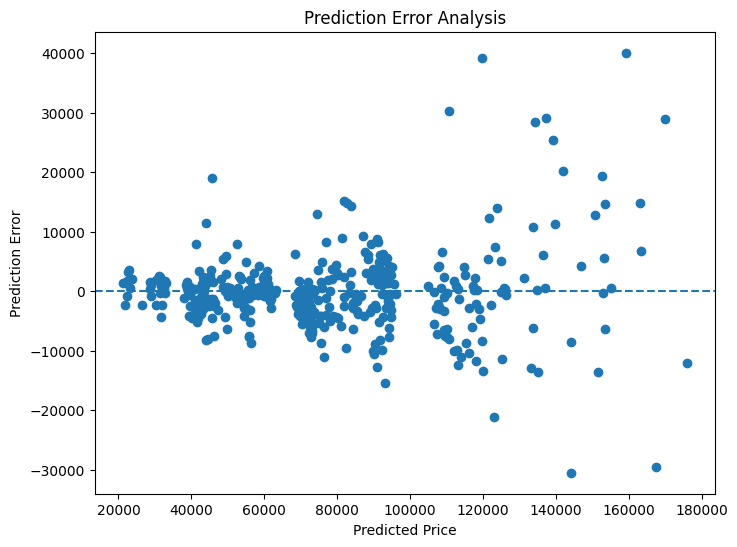

In [ ]:
errors = y_test.values - y_pred

plt.figure(figsize=(8, 6))

plt.scatter(y_pred, errors)

plt.axhline(y=0, linestyle="--")

plt.xlabel("Predicted Price")
plt.ylabel("Prediction Error")
plt.title("Prediction Error Analysis")

plt.show()

Step 21 - Saved your saved pipeline

In [ ]:
import joblib

joblib.dump(pipeline, "ev_price_prediction_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [ ]:
from google.colab import files

files.download("ev_price_prediction_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>